In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/refs/heads/master/data/Advertising.csv')

data.drop('Unnamed: 0',axis = 1,inplace= True)
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
data.shape

(200, 4)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
X = data.iloc[:,:-1]
y = data.iloc[:,-1]

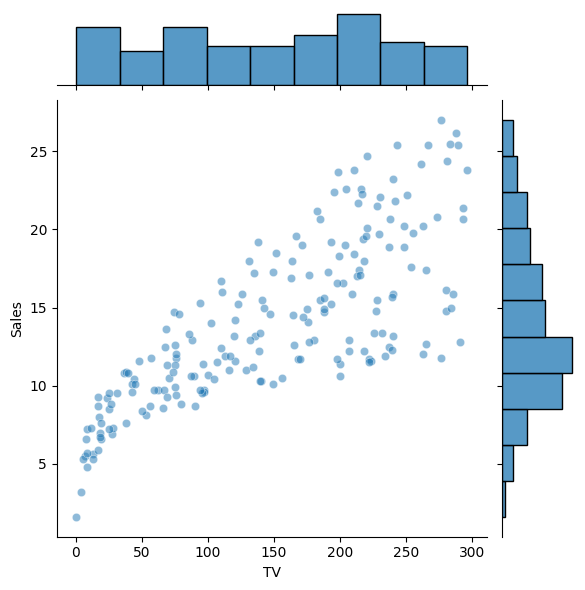

In [6]:
sns.jointplot(x = 'TV',y = 'Sales',data=data,joint_kws={"alpha": 0.5})

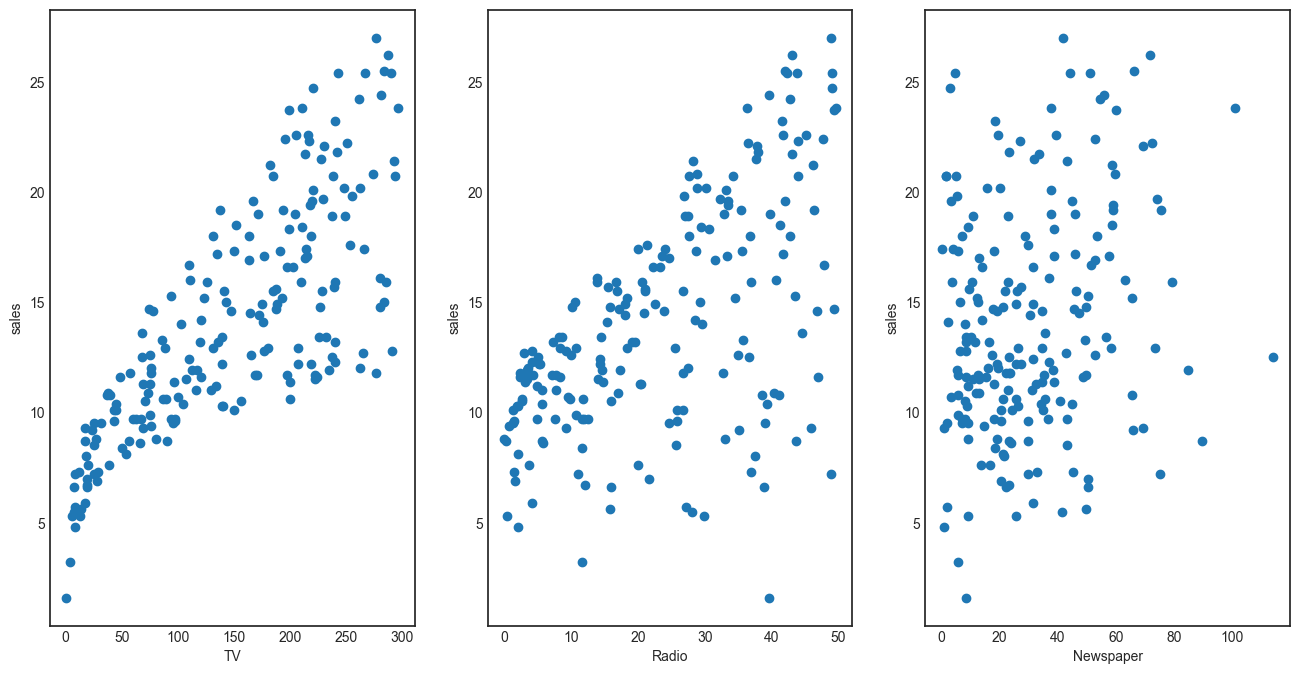

In [7]:
plt.style.use('seaborn-v0_8-white')
fig,axes = plt.subplots(1,3,figsize=(16,8))
for col,ax in zip(X.columns,axes.flat):
    ax.scatter(X[col],y)
    ax.set_ylabel('sales')
    ax.set_xlabel(col);

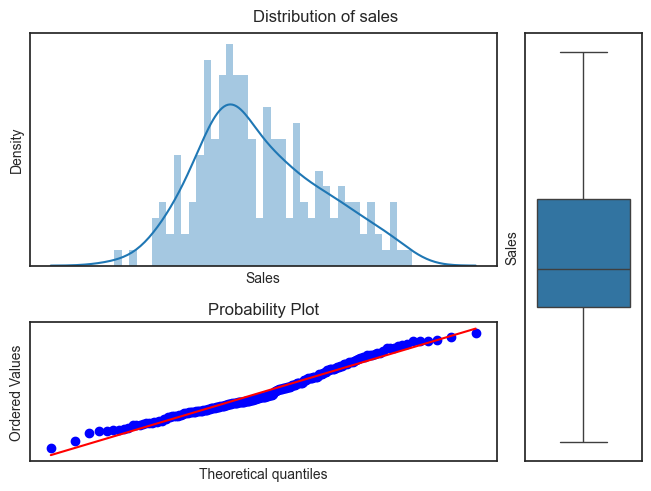

In [8]:
import scipy.stats as stats
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings(action = 'ignore')
fig = plt.figure(layout='constrained')
gs = GridSpec(5,5,figure=fig)
ax1 = fig.add_subplot(gs[:3,:-1])
ax2 = fig.add_subplot(gs[3:,:-1])
ax3 = fig.add_subplot(gs[:,-1])

sns.distplot(y,ax = ax1,bins = 40)
sns.boxplot(y,ax=ax3)
stats.probplot(y,dist='norm',plot=ax2)
ax1.set_xticks([])
ax1.set_yticks([])
ax2.set_xticks([])
ax2.set_yticks([])
ax3.set_xticks([])
ax3.set_yticks([])
fig.suptitle("Distribution of sales")
plt.show()

In [9]:
X = data.iloc[:,:-1]
X = np.concat([np.ones(len(X)).reshape(-1,1),X.values],axis=1)

In [10]:
np.set_printoptions(suppress=True,precision=8)
theta = (np.linalg.inv(X.T @ X)) @ (X.T @ y)
theta

array([ 2.93888937,  0.04576465,  0.18853002, -0.00103749])

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(160, 4)
(160,)
(40, 4)
(40,)


In [17]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = model.predict(X_test)
print(y_pred.shape)

(40,)


In [28]:
from sklearn.metrics import r2_score

score = r2_score(y_test,y_pred)
print(score)
#R² score measures the proportion of the variance in the target variable that is explained by the regression model.

0.906978827276235


In [31]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model,X,y,cv=5)
print(scores.mean())

# Cross-validation evaluates the model on multiple train-test splits.
# With cv=5, the dataset is divided into 5 equal folds.
# In each iteration:
#   - 4 folds are used for training.
#   - 1 fold is used for testing.
# Every fold is used as the test set exactly once.
# The final score is the average of the 5 R² scores, giving a more reliable
# estimate of the model's performance than a single train-test split.

0.8871063495438436
